## Calculation of wall thickness according to EN 13480
Based on EN 13480-3:2024

From section 6. the wall thickness is calculated using lame's equation 

For $D_o/D_i\le1.7$
$$
\begin{align*}
    e = \frac{p_c D_o}{2 f z + p_c} \\  e = \frac{p_c D_i}{2 f z - p_c}
\end{align*} 
$$

For $D_o/D_i>1.7$
$$
\begin{align*}
    e = \frac{D_o}{2} \left(  1- \sqrt{\frac{f z-p_c}{f z+p_c}}  \right) \\  e = \frac{D_i}{2} \left(   \sqrt{\frac{f z+p_c}{f z-p_c}}-1  \right)
\end{align*} 
$$

Where $z$ is the joint coefficient, for pressure parts the joint coefficient is always 1. 



Design stress

the design stress $f$ is given as 

$$
f = \min \left(  \frac{R_{eh,t}}{1.5} \text{ or } \frac{R_{p 0.2 t} }{1.5}; \frac{R_m}{2.4} \right)
$$

For values between linear interpolation may be used, (note 1 p.25)

For materials with time dependent material properties at that specific temperature (creep) the design stress is given as 
$$
f_{cr} = \frac{S_{RTt}}{Sf_{cr}}
$$

Where the safety factor $Sf_{cr}$ is 1.5 for a design lifetime of 200 000 hours without surveillance of creep. And $S_{RTt}$ is the mean value of creep rupture strength obtained from material standards.

In [131]:
import os 
import numpy as np
import pandas as pd


class Material():
    def __init__(self, name):
        self.name = name
        self._read_material_data()
    
    def _read_material_data(self):
        path = f'MaterialData\\{self.name}.xlsx'
        
        # Check if path exists
        if not os.path.exists(path):
            raise FileNotFoundError(f"Material data file for {self.name} not found",
                                    f"""\n It must be in 'MaterialData' subfolder and named '{self.name}.xlsx'""")
        # Read info from first sheet
        information_dataframe = pd.read_excel(path, sheet_name='Data',header=None)
        self.information = dict(information_dataframe.values)
        
        self.TensileStrength = self.information['Tensile']
        self.Elongation = self.information['Elongation']
        
        def convert_data_to_numpy(Sheet_name):
            return pd.read_excel(path, sheet_name=Sheet_name)
            
        self.ProofData = convert_data_to_numpy('Proof')
        self.CreepData = convert_data_to_numpy('Creep')
    
    def design_stress(self, temperature):
        '''Returns design stress at given temperature [C]'''
        # Interpolate in ProofData
        def interpolate_np(df):
            '''Interpolate in given dataframe and return design stress at given temperature'''
            temperatures = df["T"].to_numpy()
            stresses = df["R"].to_numpy()
            return np.interp(temperature, temperatures, stresses)
        
        def check_creep():
            '''Check if temperature is below creep range'''
            if temperature < self.CreepData["T"][0]:
                return False
            else:
                return True
    
        R_proof = interpolate_np(self.ProofData)
        R_creep = interpolate_np(self.CreepData)
        R_tensile = float(self.TensileStrength)
        
        if check_creep() == False:
            f = min(R_proof/1.5, R_tensile/2.4 )
        else:
            f = min(R_proof/1.5, R_tensile/2.4 , R_creep/1.5)

        return f
    
P235 = Material('P235GH')
P265 = Material('P265GH')

def calculate_wall(pressure,temperature,tube_OD,material):
    pressure = pressure * 0.1 # bar to MPa
    e = (pressure*tube_OD)/(2*material.design_stress(temperature)+pressure)
    return e

e_P235 = calculate_wall(134,360,31.8,P235)
e_P265 = calculate_wall(134,360,31.8,P265)

print("Calculated wall thickness [mm]:")
print(f"For P235GH: {e_P235}")
print(f"For P265GH: {e_P265}")

Calculated wall thickness [mm]:
For P235GH: 2.4880498248345657
For P265GH: 2.1355830270631473


To account for losses in the wall thickness the required wallthickness is given as (Figure 4.3-1)
$$
e_r = e + c_0 + c_1 
$$

Where $c_0$ is the expected change in wallthickness resulting from corrosion or erosion. Since the water follows EN 12952-12 it is extremly clean and no errosion or corrosion happens on the inside. Because of the complex composition of the fluegas the outside experinces corrosion on the order of 1 mm (based on BWE experience).

$c_1$ is the allowance for tolerances. For tubes made according to EN 10216-2 when ordered with outside diameter and wall thickness the tolerance is given as.

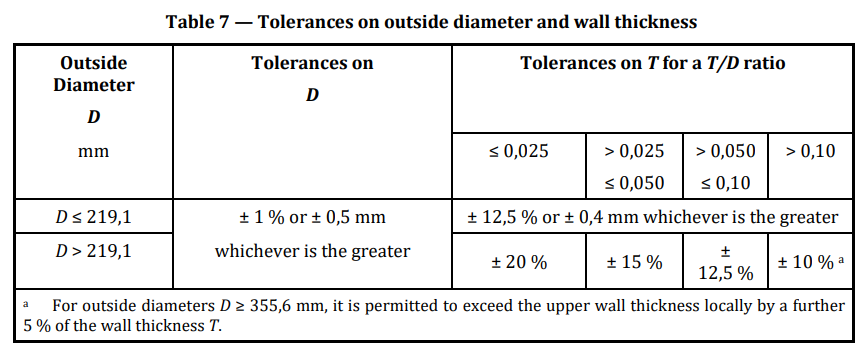


In [136]:
def determine_tolerace(D,T):
    '''Determine manufacturing tolerance based on diameter and wall thickness'''
    if D <= 219.1:
        tol = max(T * 0.125,0.4)
    else: 
        raise NotImplementedError("Tolerance determination for diameters above 219.1 mm not implemented")
    
    return tol
determine_tolerace(31.8,2.9)

size_list = [1, 1.2, 1.4, 1.6, 1.8, 2, 2.3, 2.6, 2.9, 3.2, 3.6, 4]
c_0 = 1
def determine_size(e):
    '''Determine suitable wall thickness size from size list'''
    for size in size_list:
        c_1 = determine_tolerace(31.8,size)
        if size > e + c_0 + c_1:
            print(f"Wall thickness: {size} mm, Required wall thickness including tolerance: {e+c_0+c_1} mm")
            break
print("Determined nominal wall thickness: ")
print("For P235GH: ")
determine_size(e_P235)
print("For P265GH: ")
determine_size(e_P265)

Determined nominal wall thickness: 
For P235GH: 
Wall thickness: 4 mm, Required wall thickness including tolerance: 3.9880498248345657 mm
For P265GH: 
Wall thickness: 3.6 mm, Required wall thickness including tolerance: 3.5855830270631475 mm
